In [1]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols

from Funciones import *

In [4]:
# Abrir archivo raw_data
data_folder = "../../data/stocks"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Beta                        100 non-null    float64 
 1   DividendYield               100 non-null    float64 
 2   EnterpriseToEbitda          100 non-null    float64 
 3   ReturnOnAssets              100 non-null    float64 
 4   profitMargins               100 non-null    float64 
 5   operatingMargins            100 non-null    float64 
 6   currentRatio                100 non-null    float64 
 7   revenueGrowth               100 non-null    float64 
 8   shortPercentOfFloat         100 non-null    float64 
 9   PriceToBook_Transformed     100 non-null    float64 
 10  returnOnEquity_Transformed  100 non-null    float64 
 11  ForwardPE_log               100 non-null    float64 
 12  MarketCap_log               100 non-null    float64 
 13  debtToEquity_log     

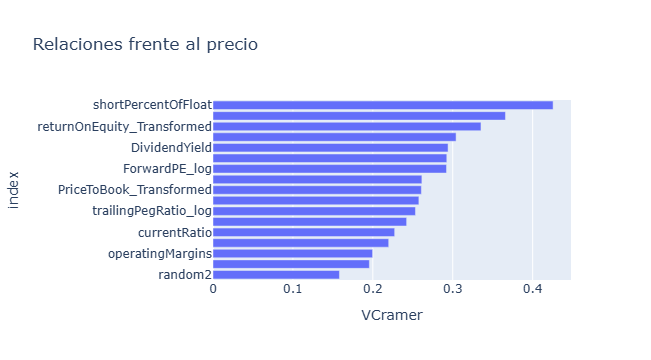

In [6]:
# Generar aleatorios
df['random1'] = np.random.uniform(0,1,size=df.shape[0])
df['random2'] = np.random.uniform(0,1,size=df.shape[0])

# Se separan las variables objetivo y los inputs de predictores
varObjCont = df['MarketCap_log']

imput = df.drop(['MarketCap_log', 'Ticker'],axis=1)

# Ranking V de Cramer vs. obj continua
tablaCramer = pd.DataFrame(imput.apply(lambda x: cramers_v(x,varObjCont)),columns=['VCramer'])

px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relaciones frente al precio').update_yaxes(categoryorder="total ascending")

In [7]:
# Matriz de correlaciones
corr = imput.select_dtypes(include=np.number).corr()
corr.style.background_gradient(cmap='viridis').format(precision=3)

,Beta,DividendYield,EnterpriseToEbitda,ReturnOnAssets,profitMargins,operatingMargins,currentRatio,revenueGrowth,shortPercentOfFloat,PriceToBook_Transformed,returnOnEquity_Transformed,ForwardPE_log,debtToEquity_log,trailingPegRatio_log,random1,random2
Beta,1.000,-0.396,0.318,0.152,0.183,0.076,0.302,0.331,-0.073,0.186,-0.012,0.196,-0.199,-0.059,-0.135,-0.011
DividendYield,-0.396,1.000,-0.171,-0.250,-0.344,-0.187,-0.355,-0.363,0.408,-0.326,-0.310,-0.425,0.331,0.142,0.120,-0.051
EnterpriseToEbitda,0.318,-0.171,1.000,0.082,0.028,0.064,0.186,-0.095,-0.070,0.091,-0.176,0.330,-0.273,0.302,-0.105,-0.150
ReturnOnAssets,0.152,-0.250,0.082,1.000,0.561,0.549,0.191,0.341,-0.183,0.164,0.535,0.116,-0.154,-0.111,-0.256,-0.045
profitMargins,0.183,-0.344,0.028,0.561,1.000,0.874,0.246,0.341,-0.426,0.115,0.425,-0.009,-0.179,-0.192,-0.158,0.017
operatingMargins,0.076,-0.187,0.064,0.549,0.874,1.000,0.198,0.268,-0.266,-0.002,0.349,-0.110,-0.146,-0.225,-0.086,-0.081
currentRatio,0.302,-0.355,0.186,0.191,0.246,0.198,1.000,0.158,-0.055,0.098,-0.082,0.180,-0.516,-0.075,0.062,-0.156
revenueGrowth,0.331,-0.363,-0.095,0.341,0.341,0.268,0.158,1.000,-0.321,0.267,0.393,0.098,-0.019,-0.392,-0.216,-0.014
shortPercentOfFloat,-0.073,0.408,-0.070,-0.183,-0.426,-0.266,-0.055,-0.321,1.000,-0.126,-0.374,-0.240,0.112,0.160,0.246,0.029
PriceToBook_Transformed,0.186,-0.326,0.091,0.164,0.115,-0.002,0.098,0.267,-0.126,1.000,0.473,0.330,0.141,0.110,0.017,-0.131


In [8]:
# Formula modelo
form = ols_formula(df, "MarketCap_log", 'Ticker')

In [9]:
form

'MarketCap_log ~ Beta + DividendYield + EnterpriseToEbitda + ReturnOnAssets + profitMargins + operatingMargins + currentRatio + revenueGrowth + shortPercentOfFloat + PriceToBook_Transformed + returnOnEquity_Transformed + ForwardPE_log + debtToEquity_log + trailingPegRatio_log + Sector + random1 + random2'

In [10]:
modelo1 = ols(form,data=df).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:          MarketCap_log   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     7.757
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           2.67e-12
Time:                        10:48:51   Log-Likelihood:                -84.929
No. Observations:                 100   AIC:                             221.9
Df Residuals:                      74   BIC:                             289.6
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [18]:
form2 = ols_formula(df, "MarketCap_log", 'Ticker', 'EnterpriseToEbitda', 'random1', 'random2', 'trailingPegRatio_log', 'DividendYield', 'profitMargins', 'returnOnEquity_Transformed', 'currentRatio', 'revenueGrowth', 'ReturnOnAssets')
modelo2 = ols(form2,data=df).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:          MarketCap_log   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     13.00
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           4.39e-16
Time:                        11:12:37   Log-Likelihood:                -89.246
No. Observations:                 100   AIC:                             210.5
Df Residuals:                      84   BIC:                             252.2
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep